# Exam Study

In [ ]:
# NumPy for arrays and numeric utilities.
import numpy as np
# Pandas for tabular data loading and manipulation.
import pandas as pd
# Seaborn for statistical plotting.
import seaborn as sns
# Matplotlib for base plotting controls.
import matplotlib.pyplot as plt

# train_test_split for holdout splits; StratifiedKFold/cross_validate for CV; GridSearchCV for tuning.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
# ColumnTransformer to apply different preprocessing by column type.
from sklearn.compose import ColumnTransformer
# Pipeline to chain preprocessing + model safely.
from sklearn.pipeline import Pipeline
# SimpleImputer to fill missing values.
from sklearn.impute import SimpleImputer
# StandardScaler for numeric scaling; OneHotEncoder for categorical encoding.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Classification metrics for model evaluation and error analysis.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Logistic Regression baseline classifier.
from sklearn.linear_model import LogisticRegression
# k-Nearest Neighbors baseline classifier.
from sklearn.neighbors import KNeighborsClassifier
# Random Forest baseline classifier.
from sklearn.ensemble import RandomForestClassifier

# Fixed seed for reproducible splits/results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Show more columns when inspecting DataFrames.
pd.set_option("display.max_columns", 100)

## 1) Load + quick EDA

In [ ]:
data_path = "diabetes.csv"

# Name of the classification target column.
target_col = "has_diabetes"

# Exactly four features to use for modeling.
feature_cols = ["chol", "stab.glu", "hdl", "age"]

# Columns where zero should be treated as invalid (empty here for this dataset).
zero_invalid_cols = []

df = pd.read_csv(data_path)

# Clean up column names by trimming extra spaces.
df.columns = [c.strip() for c in df.columns]

# Build binary target from glyhb if target is not already provided.
if target_col not in df.columns and "glyhb" in df.columns:
    # Convert glyhb to numeric safely (invalid strings become NaN).
    glyhb_num = pd.to_numeric(df["glyhb"], errors="coerce")
    # Label diabetes as 1 when glyhb >= 7.0, else 0; keep missing as NaN.
    df[target_col] = np.where(glyhb_num.notna(), (glyhb_num >= 7.0).astype(int), np.nan)

# Quick sanity checks for shape, sample rows, and class balance.
print("Shape:", df.shape)
display(df.head(3))
print(df[target_col].value_counts(dropna=False) if target_col in df.columns else "Set target_col")

Shape: (403, 20)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,has_diabetes
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0,0.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0,0.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0,0.0


has_diabetes
0.0    330
1.0     60
NaN     13
Name: count, dtype: int64


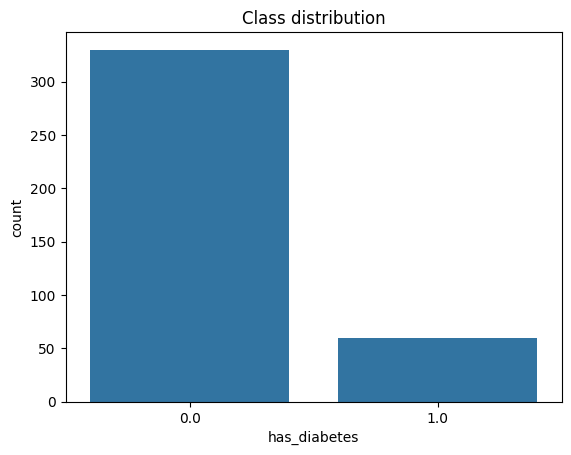

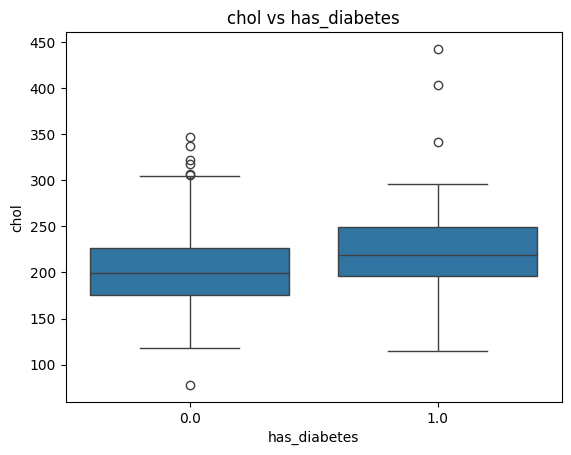

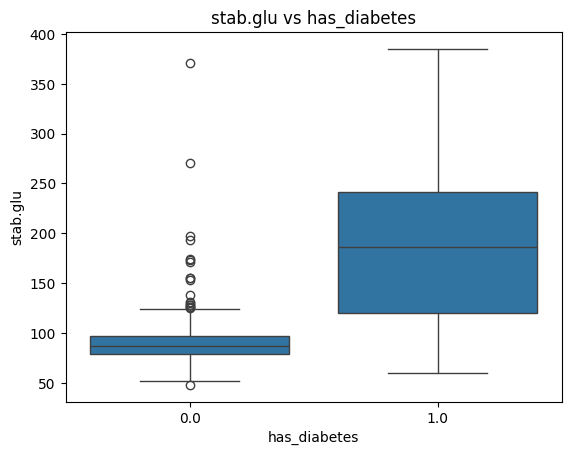

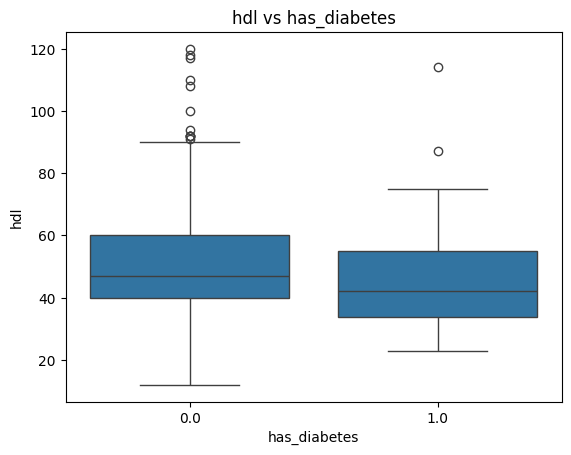

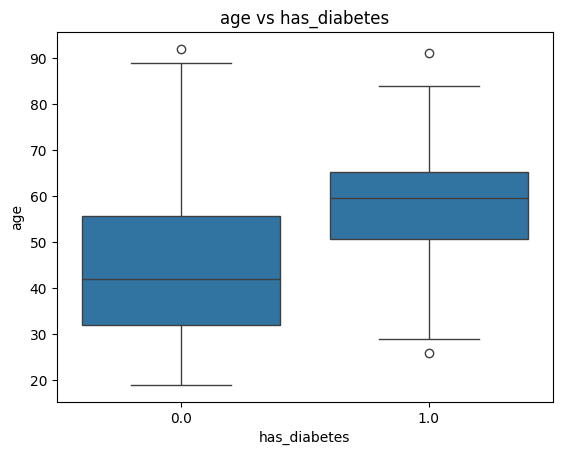

In [16]:
sns.countplot(data=df, x=target_col)
plt.title("Class distribution")
plt.show()

for col in feature_cols:
    if col in df.columns:
        sns.boxplot(data=df, x=target_col, y=col)
        plt.title(f"{col} vs {target_col}")
        plt.show()

## 2) Clean + define X/y

In [ ]:
# Keep only zero-invalid columns that actually exist in this dataset.
present_zero_invalid_cols = [c for c in zero_invalid_cols if c in df.columns]
# Replace invalid zeros with NaN so they can be removed/imputed properly.
df[present_zero_invalid_cols] = df[present_zero_invalid_cols].replace(0, np.nan)

# Columns required to build features and target.
required_cols = [c for c in feature_cols + [target_col] if c in df.columns]
# Drop rows missing any required value.
df_clean = df.dropna(subset=required_cols).copy()

# Build feature matrix X from selected columns.
X = df_clean[feature_cols].copy()

# Build target vector y and force integer class labels.
y = df_clean[target_col].astype(int).copy()

# Quick check of data retained after cleaning.
print("Rows before/after:", len(df), len(df_clean))
print("X shape:", X.shape, "| y shape:", y.shape)

Rows before/after: 403 389
X shape: (389, 4) | y shape: (389,)


## 3) Split 60/20/20 + preprocess

In [18]:
# 20% test holdout, then split remaining 80% into 60/20 train/val.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (233, 4) Val: (78, 4) Test: (78, 4)


In [19]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

# Put all preprocessing in pipeline to avoid leakage.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

## 4) Train 3 models + compare

In [20]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE),
}

val_rows, trained_pipelines = [], {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    val_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, average="weighted", zero_division=0),
        "recall": recall_score(y_val, pred, average="weighted", zero_division=0),
        "f1": f1_score(y_val, pred, average="weighted", zero_division=0),
    })
    trained_pipelines[name] = pipe

val_results = pd.DataFrame(val_rows).sort_values("f1", ascending=False)
display(val_results)

,model,accuracy,precision,recall,f1
0,LogReg,0.923077,0.920330,0.923077,0.916516
2,RF,0.910256,0.904496,0.910256,0.904843
1,KNN,0.897436,0.891629,0.897436,0.893539


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipe in trained_pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"], n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_f1": scores["test_f1_weighted"].mean(),
        "cv_recall": scores["test_recall_weighted"].mean(),
        "cv_precision": scores["test_precision_weighted"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),
    })
cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1", ascending=False)
display(cv_results)

,model,cv_f1,cv_recall,cv_precision,cv_accuracy
2,RF,0.938494,0.940056,0.938861,0.940056
1,KNN,0.927139,0.931175,0.929244,0.931175
0,LogReg,0.925985,0.931267,0.931191,0.931267


In [22]:
best_base_name = cv_results.iloc[0]["model"]

param_grid_map = {
    "LogReg": {"model__C": [0.1, 1, 10]},
    "KNN": {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]},
    "RF": {"model__n_estimators": [100, 200], "model__max_depth": [None, 5, 10]},
}

# Tune only the best CV baseline to save exam time.
grid = GridSearchCV(
    estimator=trained_pipelines[best_base_name],
    param_grid=param_grid_map[best_base_name],
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

print("Selected for tuning:", best_base_name)
print("Best params:", grid.best_params_)
print("Best CV f1:", grid.best_score_)

Selected for tuning: RF
Best params: {'model__max_depth': None, 'model__n_estimators': 100}
Best CV f1: 0.9384936398745694


## 5) Best model justification (markdown)
- Best model:
- Why it fits this dataset:
- Precision/Recall/F1 tradeoff (focus on missed positives):
- Production-ready? If not, what is missing:

In [23]:
# Retrain on train+val before final one-time test evaluation.
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_model = grid.best_estimator_
final_model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 6) Final test evaluation

Accuracy: 0.8717948717948718
Precision: 0.8547008547008546
Recall: 0.8717948717948718
F1: 0.8532144184318097

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        66
           1       0.67      0.33      0.44        12

    accuracy                           0.87        78
   macro avg       0.78      0.65      0.69        78
weighted avg       0.85      0.87      0.85        78



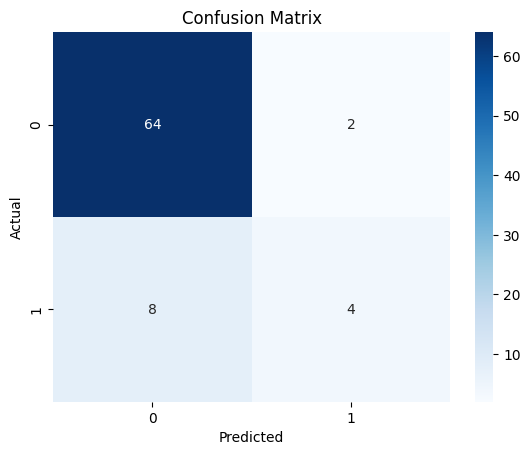

In [24]:
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)
print("\nClassification report:\n", classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
pd.DataFrame([{
    "selected_model": best_base_name,
    "best_params": grid.best_params_,
    "best_cv_f1": grid.best_score_,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
}])

,selected_model,best_params,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1
0,RF,"{'model__max_depth': None, 'model__n_estimator...",0.938494,0.871795,0.854701,0.871795,0.853214
